## HOMEWORK 4 - Logistic Regression: R → Python Bridge

**Raul Miranda**

**March 9, 2026**


## Learning Objectives

By the end of this assignment, you should be able to:

- Fit and interpret **logistic regression models**
- Translate workflows from **R (glm / tidymodels)** to **Python**
- Interpret **odds ratios**
- Evaluate classification models using **Accuracy and ROC–AUC**
- Reflect on the difference between **statistical inference vs prediction**


In [16]:
## SETUP

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

## Read dataset and create binary outcome

- `1` → expensive homes  
- `0` → less expensive homes 

The dataset contains **600 housing listings**.

| Variable | Description |
|---|---|
| listing_id | Unique identifier |
| price | Sale price of the house |
| size | House size (square footage) |
| bedrooms | Number of bedrooms |
| neighborhood | Location category |
| type | Housing type (SingleFamily, Townhouse, MultiFamily) |


In [17]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/Reben80/Data201/refs/heads/main/Dataset/housing.csv")


df["high_price"] = np.where(df["price"] > np.median(df["price"]), 1, 0)

df.head()

,listing_id,price,size,bedrooms,neighborhood,type,high_price
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse,0
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily,0
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily,0
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily,0
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily,0



## Part A – Explore the Dataset

Before modeling, briefly explore the data.

Create **at least three plots** such as:

- Histogram of `price`
- Scatter plot: `size` vs `price`
- Boxplot: `price` by `neighborhood`
- Bar chart: housing `type`

Discuss **one interesting pattern** you observe.

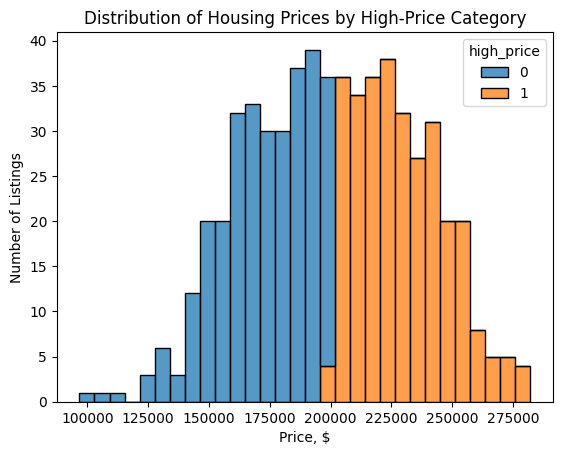

In [18]:
# Histogram of price, using seaborn histogram


sns.histplot(data=df, x="price", hue="high_price", multiple="stack", bins=30)
plt.title("Distribution of Housing Prices by High-Price Category")
plt.xlabel("Price, $")
plt.ylabel("Number of Listings")
plt.show()



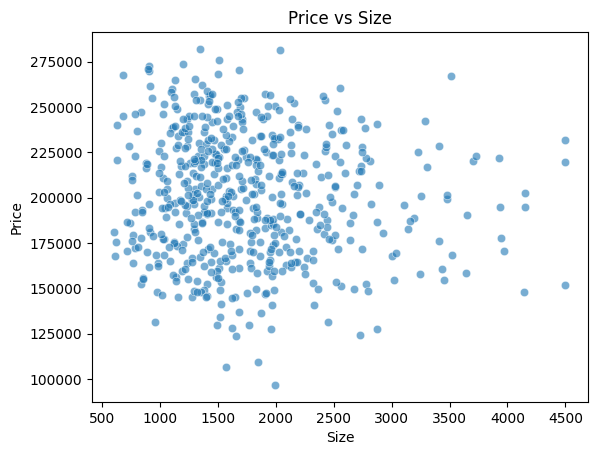

In [22]:
# Scatter plot of size vs price

sns.scatterplot(data=df, x="size", y="price", alpha=0.6)
plt.xlabel("Size")
plt.ylabel("Price")
plt.title("Price vs Size")
plt.show()

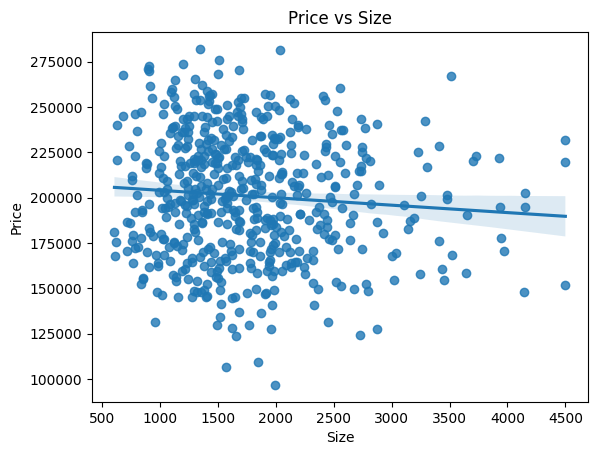

In [23]:
# scatterplot showing regression line

sns.regplot(data=df, x="size", y="price")
plt.xlabel("Size")
plt.ylabel("Price")
plt.title("Price vs Size")
plt.show()

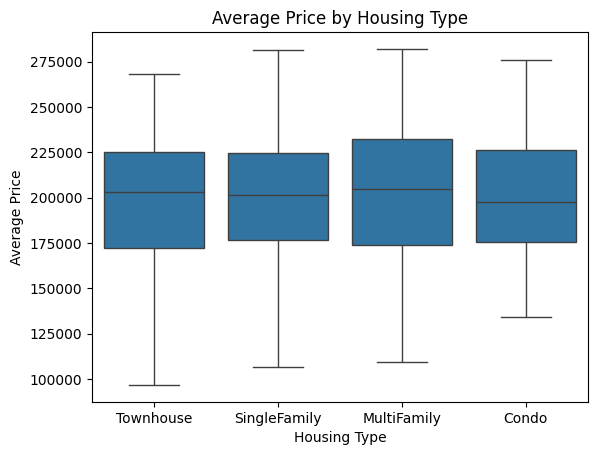

In [24]:
# boxplot showing housing type

sns.boxplot(data=df, x="type", y="price")
plt.xlabel("Housing Type")
plt.ylabel("Average Price")
plt.title("Average Price by Housing Type")
plt.show()

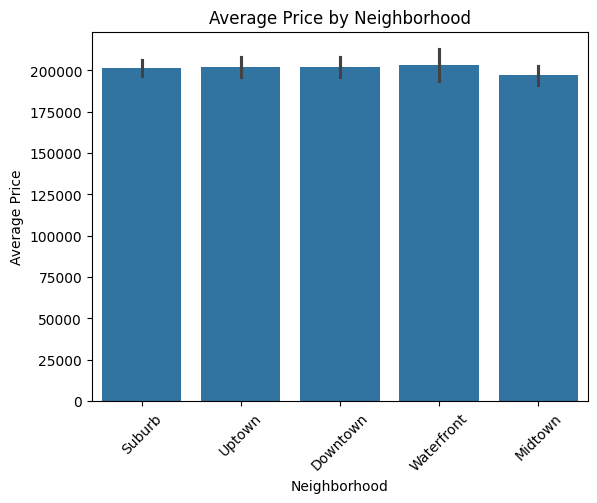

In [25]:
# bar chart of price by neigborhood

sns.barplot(data=df, x="neighborhood", y="price")

plt.xlabel("Neighborhood")
plt.ylabel("Average Price")
plt.title("Average Price by Neighborhood")
plt.xticks(rotation=45)
plt.show()

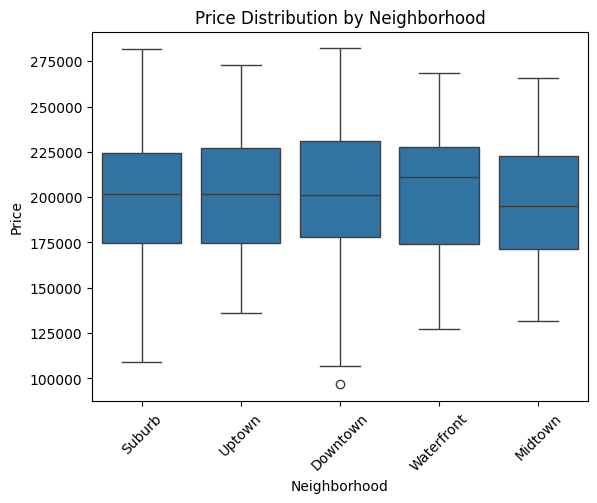

In [27]:
# boxplot of price by neighborhood

sns.boxplot(data=df, x="neighborhood", y="price")

plt.xlabel("Neighborhood")
plt.ylabel("Price")
plt.title("Price Distribution by Neighborhood")
plt.xticks(rotation=45)
plt.show()

### Reflections from the exploratory analysis

The histogram of high-priced houses shows that half the listings are classified as high-price, with a quasi normal distribution of price about the median and mean of about $200,000, minimum about 100,000 and maximum about 285,000.

The scatter plots of price vs size show a left-skewed distribution, confirming also grouping/accumulation around a median of about $200,000, as shown by the regression line (which shows the mean for each size).  A particular feature is that the slope of the line is slightly negative, i.e., prices drop with size, which is abnormal behavior for the real estate market.

The boxplots of price by type shows that Multifamily homes have a mean price of  slightly above $200,000; while the mean for Condos is under $200,000.  This folows normal real estate behavior.

The barplots and boxplots by neighborhood show that Waterfront properties have a mean price above $200,000, while Midtown mean is under $200,000; this follows normal real estate behavior. Note: boxplots seem more informative than barplots.



## Part B – Logistic Regression for Inference



In [28]:
model_lr = smf.logit(
    "high_price ~ size + bedrooms + C(neighborhood) + C(type)", data=df
).fit()

print(model_lr.summary())

Optimization terminated successfully.
         Current function value: 0.683349
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:             high_price   No. Observations:                  524
Model:                          Logit   Df Residuals:                      514
Method:                           MLE   Df Model:                            9
Date:                Mon, 09 Mar 2026   Pseudo R-squ.:                 0.01414
Time:                        16:31:13   Log-Likelihood:                -358.07
converged:                       True   LL-Null:                       -363.21
Covariance Type:            nonrobust   LLR p-value:                    0.3292
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         0.2590      0.309      0.837      0.

### Report

- coefficients
- odds ratios
- p-values

Note:  the coefficients and p-values are in the table above, the odds ratio are calculated next.

In [29]:
odds_ratios = model_lr.params.apply(np.exp)
odds_ratios

Intercept                        1.295677
C(neighborhood)[T.Midtown]       0.766643
C(neighborhood)[T.Suburb]        1.150462
C(neighborhood)[T.Uptown]        1.056716
C(neighborhood)[T.Waterfront]    1.541338
C(type)[T.MultiFamily]           1.007977
C(type)[T.SingleFamily]          1.123955
C(type)[T.Townhouse]             1.377664
size                             0.999475
bedrooms                         1.259642
dtype: float64

In [30]:
# we can also add the predicted probabilities -- to emphasize the results

df["pred_prob"] = model_lr.predict(df)
df.head()

,listing_id,price,size,bedrooms,neighborhood,type,high_price,pred_prob
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse,0,0.568976
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily,0,0.538430
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily,0,0.404653
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily,0,0.457098
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily,0,0.461202


### Short Analysis

Answer:

- Which predictors appear **statistically significant**?
- Which neighborhood has **higher odds** of expensive homes?

---

**ANSWERS**

The Pseudo-Rsqu= 0.014 shows very little explanatory power above a null model, thus not explaining significantly the variation in high_price. In logistic regression, Pseudo-Rsqu < .02 is considered weak. It should be > .2 to  be considered strong.

The p-values < 0.05 are considered statistically significant at the 5% level, thus only size (coeff. -.0005,  p: 0.037) is statistically significant.  But since the coeff is very small, the effect per unit is tiny.   Bedrooms is marginally significant (at the 10% level.)

The other coefficients (variables) are not statistically significant. Neither neighborhood nor type affect high_price significantly; however see below for relative effects.

Odds ratios for variable "size" (.999475) tell us that a 1 unit increase in size multiplies the odds of high_price by .999475, that is it DECREASES the odds.  (E.g., 100 additional sqft, will reduce the odds by about 5%), which is counterintuitive. 

Odds ratios for "bedrooms" (1.2596) says that increasing by 1 bedroom will increase the odds of being high_price by roughly 26%; although the coefficient was only marginally significant.

Neighborhood effects:
the coefficients reflect comparisons against the baseline (which is Downtown - not shown on the table).

Waterfront home (odds ratio 1.541338) says that those homes have 54% higher odds of being high-priced compared to Downtown homes. But the high p-value indicates the coeff is not statistically significant. 

Suburb home (odds ratio 1.150462) have 15% higher odds of being high-priced compared to Downtown homes, again with not a statistically significant coefficient.

House style effects:

Townhouses (odds ratio 1.377664) have 38% higher odds of being high-priced compared to the baseline,Condos (not on the list); and Single Family homes (odds ratio 1.123955) have 12% higher odds of being high-priced compared to Condos. Multi Family homes (odds ratio 1.007977) have less than 1% higher odds than Condos. In all cases, the p-values are not below 0.05 thus the statistical significance of these coefficents is questionable.






## Part C – Interpretation (Plain Language)

Choose **one variable** and explain its odds ratio.

Example:

> “For every additional bedroom, the odds of a house being expensive increase by ___.”

Your explanation should be understandable to someone **without statistics training**.


**Answers**  (partially answered above in Part A)

Effect of **size**

meaning of OR:  OR=1  means no change in the Odds of becoming a high price house.  OR>1 increasing odds. OR<1 decreasing odds. If OR= Odds(new)/Odds(original).  Then, change= Odds(new)-Odds(original) = OR*Odds(original) - Odds(original).  I.e., change= Odds (original) (OR - 1).

The odds-ratio of variable size is 0.999475. This means that a 1-sqft increase multiplies the odds by 0.999475. I.e., Odds*(0.9995 - 1) = -0.0005, or -.05% decrease of odds.

Effect of **bedrooms**

The odds-ratio of bedrooms is 1.2596, i.e., the addition of a bedroom multiplies the odds of becoming a high-priced home by 1.2596, i,e. Odds*(1.26-1) = .26, or 26% increase.

## Part D – Prediction Workflow  
### (tidymodels → scikit-learn)

### 1. Train/Test Split

Split the data:

- 80% training
- 20% testing

####  do some cleaning: replace NaNs and create dummy vars for the categorical ones

In [31]:
#  replaced NaNs (in size and bedrooms) by their means
df["size"] = df["size"].fillna(df["size"].mean())
df["bedrooms"] = df["bedrooms"].fillna(df["bedrooms"].mean())
df.isna().sum()  # check if NaNs remain

#  LogisticRegression needs all floats; it doesn't accept categorical vars natively; contrary to smf logit
df_encoded = pd.get_dummies(df, drop_first=True)   # create dummy vars for the categorical type and neighborhood

X = df_encoded.drop(columns=["listing_id", "price", "high_price","pred_prob"])
y = df_encoded["high_price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)

### 2. Fit Logistic Regression

In [32]:
model_sk = LogisticRegression(max_iter=1000)
model_sk.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### 3. Evaluate the Model ( check slides for more info about this)

Report:

- **Accuracy**
- **ROC–AUC**

In [33]:
# generate class predictions and predicted probabilities

y_pred = model_sk.predict(X_test)
y_prob = model_sk.predict_proba(X_test)[:, 1]

In [34]:
# Compute accuracy

accuracy_score(y_test, y_pred)

0.5083333333333333

In [35]:
# Compute confusion matrix

confusion_matrix(y_test, y_pred)

array([[29, 30],
       [29, 32]])

AUC Score: 0.5270908585718255


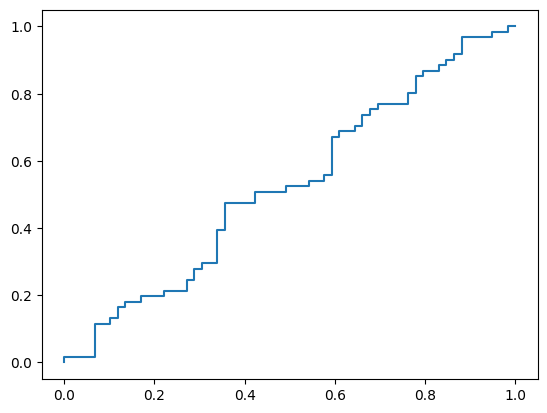

In [36]:
# Plot ROC curve and compute AUC

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)

auc = roc_auc_score(y_test, y_prob)
print(f"AUC Score: {auc}")

## Part E – Model Understanding

### Accuracy vs AUC

Why might **ROC–AUC** sometimes be preferred over **accuracy**?

**Answer**  ROC-AUC yields the absolute number and also the curve as a visual indication of accuracy. The curve plots True Positive rate versu False Positive rate, and thus must deviate significantly from the diagonal (slope 0.5) for the model to have discriminition power, ie. to give better than a random choice. In this case, the ROC is almost diagonal indicating a very poor ability for this model to classify high-price vs not high-price on the basis of the parameters used.


Explain in **2–3 sentences**.

### Inference vs Prediction

Which modeling approach would you choose for:

- **Policy analysis**
- **Prediction tasks**

**Answer**  

For Policy analysis I would choose statsmodels logit approach. The purpose is to understand the relationship between variables and test statistical significance by means of the p-values of coefficients, confidence intervals, standard errors, and the odds ratios.

For Prediction tasks I would choose scikit learn Logistic Regression. The purpose is to predict class or probabilities on unseen data.  Scikit learn can be integrated with ML pipelines.

